# 통계 기초

## 통계가 필요한 이유
- 통계: 데이터를 숫자로 요약하고 판단 근거를 만드는 도구
- NumPy: 평균, 중앙값, 분산, 표준편차 계산 가능

![image.png](attachment:61c60cec-1790-422e-acff-c69dab5bf57e.png)

### 1. 모집단과 표본
- 모집단: 알고 싶은 전체 대상
- 표본: 모집단에서 일부만 뽑은 데이터
- 전체 조사가 어려울 때 표본으로 모집단 특성을 추정

### 2. 기술통계와 추론통계
- 기술통계: 현재 가진 데이터를 요약하는 방법
- 추론통계: 표본으로 모집단을 추정하거나 가설을 검정하는 방법

### 3. 중심 경향 측도
- 평균: 전체 합을 개수로 나눈 대표값
- 중앙값: 정렬했을 때 가운데 위치한 값
- 최빈값: 가장 자주 등장한 값
- 평균은 이상치 영향이 크다
- 중앙값은 이상치 영향이 상대적으로 작다

```text
점수: 60, 75, 80, 85, 90
평균: 78
중앙값: 80
```

### 4. 산포 측도
- 범위: 최댓값과 최솟값의 차이
- 분산: 평균에서 떨어진 거리의 제곱 평균
- 표준편차: 분산의 제곱근
- 표준편차는 원래 데이터 단위로 해석 가능
- `np.var()`: 기본적으로 모집단 분산 계산
- 표본 분산: `ddof=1` 지정

```python
np.var(scores, ddof=0)  # 모집단 분산
np.var(scores, ddof=1)  # 표본 분산
```

### 5. 확률분포와 정규분포
- 확률: 사건 발생 가능성을 나타내는 값
- 확률분포: 값이 얼마나 자주 나올 수 있는지 나타낸 것
- 정규분포: 평균 주변에 데이터가 많이 모이는 종 모양 분포
- 정규분포의 평균, 중앙값, 최빈값은 같은 위치
- 대표 규칙: 68-95-99.7 규칙


## 수업용 직관 예시
- 평균, 중앙값, 분산, 표준편차를 한 번에 설명하기 위한 예시
- 이상치가 있으면 평균이 크게 흔들릴 수 있음
- 평균이 같아도 데이터의 퍼짐은 다를 수 있음
- 퍼짐을 숫자로 표현한 값이 분산과 표준편차


In [1]:
import numpy as np

In [2]:
# 평균과 중앙값
# - 중앙값을 사용하는 경우 : 데이터 중 이상치가 존재할 때
scores1 = np.array([70,75,80,85,90])
scores2 = np.array([70,75,80,85,300])

print("scores1 평균:", scores1.mean())
print("scores1 중앙값:", np.median(scores1))   # NumPy 중앙값 함수

print("scores2 평균:", scores2.mean())
print("scores2 중앙값:", np.median(scores2))

scores1 평균: 80.0
scores1 중앙값: 80.0
scores2 평균: 122.0
scores2 중앙값: 80.0


In [3]:
# 분산과 표준편차
class_a = np.array([78, 79, 80, 81, 82])
class_b = np.array([50, 65, 80, 95, 110])

print("a반의 평균",np.mean(class_a))
print("a반의 분산",np.var(class_a))
print("a반의 표준편차",np.std(class_a))

print("b반의 평균",np.mean(class_b))
print("b반의 분산",np.var(class_b))
print("b반의 표준편차",np.std(class_b))

a반의 평균 80.0
a반의 분산 2.0
a반의 표준편차 1.4142135623730951
b반의 평균 80.0
b반의 분산 450.0
b반의 표준편차 21.213203435596427


## 중심 경향 측도
- 데이터의 대표값을 보는 지표
- 평균, 중앙값, 최빈값 포함


In [4]:
scores = np.array([85, 90, 92, 88, 90, 75, 88, 95, 92, 85, 80, 95, 100, 92, 85])

In [5]:
# 평균, 충앙값
print("scores 평균: ", np.mean(scores))
print("scores 중앙값: ", np.median(scores))

# 중복값 제거 : np.unique()
print("scores 중복값 제거: ", np.unique(scores))

# 최빈값: 가장 자주 등장하는 값
# -> np.unique(ndarray, return_counts=True)
# return_counts=True 옵션 : 중복을 제거하면서 같은 값이 몇개 있는지 카운트해서 반환
values,counts = np.unique(scores, return_counts=True)
print(values)
print(counts)

max_count = np.max(counts)  # 3
print("max_count: ",max_count)
print(counts==max_count)

#중복 제거된 배열에서 최빈값을 가진 수만 찾기
vals=values[counts==max_count]
print("최빈값: ",vals)

scores 평균:  88.8
scores 중앙값:  90.0
scores 중복값 제거:  [ 75  80  85  88  90  92  95 100]
[ 75  80  85  88  90  92  95 100]
[1 1 3 2 2 3 2 1]
max_count:  3
[False False  True False False  True False False]
최빈값:  [85 92]


In [6]:
# defaultdict는 없는 키를 처음 만났을 때 기본값을 자동으로 만들어줌.
# 여기서는 점수를 key로, 등장 횟수를 value로 누적한다.

# 최빈값 (collections.defaultdict)
from collections import defaultdict

# defaultdict: 기본값을 제공하는 dict
counts_dict = defaultdict(int) # int기본값(0) 사용
print("counts_dict:", counts_dict)

for score in scores:
    # 해당키값에 대한 선언을 생략 가능
    counts_dict[score] += 1

print("counts_dict:", counts_dict)

max_count = np.max(list(counts_dict.values()))
print(f'최대빈도수: {max_count}')

vals = [key for key in counts_dict if counts_dict[key] == max_count]
print(f'최빈값: {vals}')

counts_dict: defaultdict(<class 'int'>, {})
counts_dict: defaultdict(<class 'int'>, {np.int64(85): 3, np.int64(90): 2, np.int64(92): 3, np.int64(88): 2, np.int64(75): 1, np.int64(95): 2, np.int64(80): 1, np.int64(100): 1})
최대빈도수: 3
최빈값: [np.int64(85), np.int64(92)]


## 산포 측도
- 데이터가 대표값 주변에 얼마나 퍼져 있는지 보는 지표

### 분산
- 평균에서 떨어진 거리의 제곱 평균
- 편차를 그냥 더하면 양수/음수가 상쇄될 수 있다
- 제곱을 사용해 퍼짐의 크기를 계산
- 단위가 제곱되어 직관적 해석은 어려움

**계산 순서**
1. 평균을 구한다
2. 각 값에서 평균을 뺀다
3. 뺀 값을 제곱한다
4. 제곱값들의 평균을 구한다

### 표준편차
- 분산에 제곱근을 씌운 값
- 원래 데이터와 같은 단위로 해석 가능
- 분산보다 직관적

```text
표준편차 = √분산
```

### 모집단 분산과 표본 분산
| 구분 | NumPy 코드 | 나누는 값 | 수업용 해석 |
|---|---|---:|---|
| 모집단 분산 | `np.var(scores, ddof=0)` | `n` | 전체 데이터를 모두 가진 경우 |
| 표본 분산 | `np.var(scores, ddof=1)` | `n - 1` | 일부 표본으로 전체를 추정하는 경우 |

- `ddof`: Delta Degrees of Freedom의 약자
- NumPy는 `n - ddof`로 나누어 분산 계산

**공식 표현**
- 모집단 분산 = `Σ(값 - 모집단평균)² / N`
- 표본 분산 = `Σ(값 - 표본평균)² / (n - 1)`


In [7]:
# 분산(Variance)
# - 분산 = (값-평균)^2한 값들의 평균
mean_score = np.mean(scores)
a = scores-mean_score
#print(a)
b = a**2
#print(b)

print("평균:", mean_score)
print("편차:", a)
print("편차 제곱:", b)
print("분산:", np.mean(b))
print("표준편차:", np.sqrt(np.mean(b)))

평균: 88.8
편차: [ -3.8   1.2   3.2  -0.8   1.2 -13.8  -0.8   6.2   3.2  -3.8  -8.8   6.2
  11.2   3.2  -3.8]
편차 제곱: [ 14.44   1.44  10.24   0.64   1.44 190.44   0.64  38.44  10.24  14.44
  77.44  38.44 125.44  10.24  14.44]
분산: 36.559999999999995
표준편차: 6.046486583132389


In [8]:
# NumPy를 이용한 분산과 표준편차
# ddof=0
# 모집단에 대한 분산, 표준편차
print("분산:", np.var(scores, ddof=0))
print("표준편차:", np.std(scores, ddof=0))

분산: 36.559999999999995
표준편차: 6.046486583132389


In [9]:
# ddof=1
# 표본에 대한 분산, 표준편차
print("분산:", np.var(scores, ddof=1))
print("표준편차:", np.std(scores, ddof=1))

분산: 39.17142857142857
표준편차: 6.258708219067939


## 확률분포
- 어떤 값이 얼마나 자주 나올 수 있는지 나타낸 것

### `np.random`
- 다양한 분포에서 난수를 만들 때 사용하는 NumPy 모듈
- `np.random.normal(loc, scale, size)`: 정규분포 난수 생성
- `np.random.randn(...)`: 표준정규분포 난수 생성
- `np.random.randint(low, high, size)`: 정수 난수 생성
- `np.random.rand(...)`: 0 이상 1 미만 균등분포 실수 난수 생성
- 분포 학습 시 숫자와 그래프를 함께 확인하는 것이 좋음


In [10]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.3 MB 13.1 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.3 MB 8.8 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 13.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 14.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
  

In [11]:
# Matplotlib은 기본 폰트가 한글을 지원하지 않아 경고가 날 수 있습니다.
# 운영체제별 후보 폰트 중 실제 설치된 폰트를 찾아 그래프 제목/축 라벨이 깨지지 않게 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Matplotlib 기본 폰트(DejaVu Sans)는 한글 글리프가 없어 경고가 날 수 있습니다.
# 운영체제별로 사용 가능한 한글 폰트를 찾아 설정합니다.
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
system_name = platform.system()
selected_font = None

for font_name in font_candidates.get(system_name, []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Noto Sans KR 설치가 필요할 수 있습니다.")

# 마이너스 기호가 깨지는 문제 방지
plt.rcParams["axes.unicode_minus"] = False

설정된 한글 폰트: Malgun Gothic


#### 정규분포
- 평균 주변에 데이터가 많이 모이는 분포
- 평균에서 멀어질수록 빈도가 줄어듦
- 종 모양 분포


In [14]:
# np.random.normal(loc, scale, size)
# - loc : 평균값
# - scale : 표준편차
# - size : 생성할 난수의 개수
# - 평균값(loc)으로 중심 위치를 잡고,
#   표준편차(scale)로 값들이 퍼지는 범위를 조절
# -> 난수들이 표준편차 번위 내에서 생성됨

# 평균=10, 표준펹차=1, 10행 10열 크기
arr = np.random.normal(10,1,(10,10))
# print(arr)

print("평균:",np.mean(arr))
print("분산:",np.var(arr,ddof=0))      # 모분산(ddof=0)
print("표준편차:",np.std(arr,ddof=0))   # 모표준편차(ddof=0)

평균: 10.003391038528951
분산: 0.8558988969237065


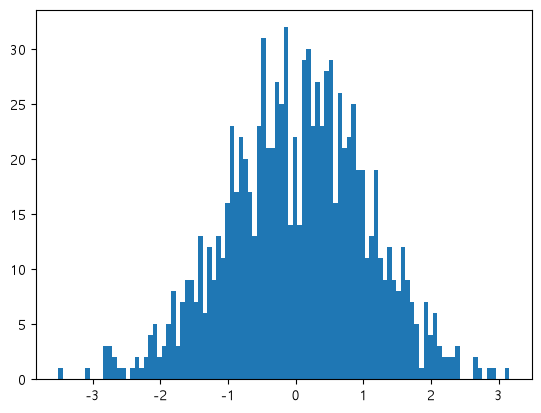

In [17]:
# 히스토그램을 이용한 시각화
# -> 정규분포 데이터가 평균 근처에 몰려있는 것을 확인

arr = np.random.normal(0,1,1000)
plt.hist(arr, bins=100)
plt.show()

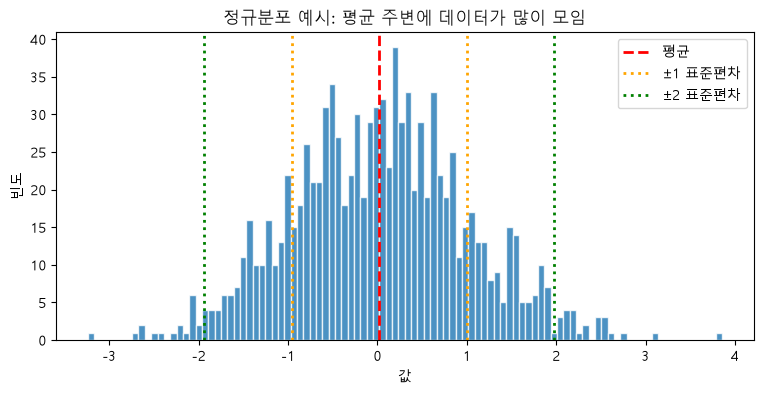

In [18]:
np.random.seed(42)
arr = np.random.normal(loc=0, scale=1, size=1000)

mean = np.mean(arr)
std = np.std(arr)

plt.figure(figsize=(9, 4))
plt.hist(arr, bins=100, edgecolor="white", alpha=0.8)
plt.axvline(mean, color="red", linestyle="--", linewidth=2, label="평균")
plt.axvline(mean - std, color="orange", linestyle=":", linewidth=2, label="±1 표준편차")
plt.axvline(mean + std, color="orange", linestyle=":", linewidth=2)
plt.axvline(mean - 2 * std, color="green", linestyle=":", linewidth=2, label="±2 표준편차")
plt.axvline(mean + 2 * std, color="green", linestyle=":", linewidth=2)
plt.title("정규분포 예시: 평균 주변에 데이터가 많이 모임")
plt.xlabel("값")
plt.ylabel("빈도")
plt.legend()
plt.show()

In [21]:
# np.random.randn(size) : 평균0, 표준편차1 범위의 난수를 size개 생성
# arr = np.random.randn(100)
arr = np.random.randn(5,20)
arr

array([[ 0.1252245 , -0.42940554,  0.1222975 ,  0.54329803,  0.04886007,
         0.04059169, -0.70199169, -0.66290092, -1.40260527,  1.74957674,
        -1.24386324, -0.6929052 , -0.71840727,  0.89492438, -0.29494968,
         1.24774207, -0.67349062,  0.27899416, -0.83534705,  2.14514913],
       [-1.18759842,  0.30982071,  0.63377688,  0.4137991 , -0.18528766,
        -0.1298207 ,  0.04381147, -0.147002  ,  0.96387912,  2.210523  ,
        -0.55749179, -1.36980298, -0.08828205,  2.57970934, -0.80367457,
         1.63911681,  1.67770081, -0.55358824,  0.56898308,  1.62839662],
       [-0.37912774, -0.20358036, -0.58168091, -1.01475673, -0.64927755,
        -1.22394027,  0.03408347, -0.76997323,  0.23378591, -1.55589565,
         0.33088023,  0.83352896, -1.99373564,  0.37405657,  1.22766899,
        -1.20964102,  1.67257239,  0.41901901, -0.70501186, -0.05576908],
       [ 0.55832691,  0.07600539,  0.53875599, -0.92067359,  0.16936082,
        -1.4137145 , -0.11122606, -0.90390764, -

#### 균등분포
- 각 값 또는 구간이 비슷한 확률로 나오는 분포
- 특정 구간에 치우침이 적음


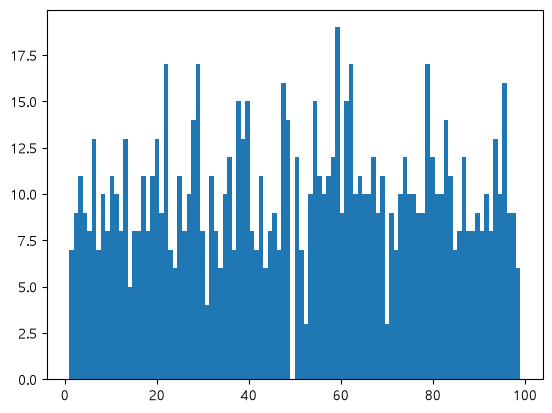

In [24]:
# np.random.randint(low,high,size
arr = np.random.randint(1,100,1000)
# arr

plt.hist(arr,bins=100)
plt.show()

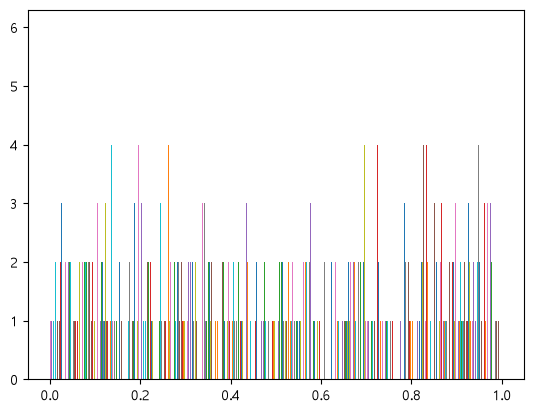

In [26]:
# np.random.rand(size) : 0~1 사이 균등분포 난수 생성
# arr = np.random.rand(1000)
arr = np.random.rand(100,100)
plt.hist(arr,bins=100)
plt.show()

#### 그 외
- `seed`: 난수 결과 재현을 위한 시작값
- `choice`: 배열에서 무작위 선택하는 함수
- `replace=True`: 복원추출
- `replace=False`: 비복원추출


In [28]:
# seed : 난수 생성 결과를 재현하기 위한 시작 값
np.random.seed(333)
random_values = np.random.rand(2,3)
print(random_values)

[[0.54329109 0.72895073 0.01688145]
 [0.3303388  0.36872182 0.04830367]]


In [30]:
# np,rnadom.choice(ndarray) : 배열 내에서 무작위값 추출
arr = np.array([10,3,5,7,8,9])
print("1개 무작위 추출:",np.random.choice(arr))

# np.random.choice(ndarray,size,replace)
# - 배열 내에서 무작위 값을 size만큼 추출
# - replace = True : 복원추출
# - replace = False : 비복원추출
print("3개 무작위 추출(복원추출):",np.random.choice(arr,size=3))
print("3개 무작위 추출(비복원추출):",np.random.choice(arr,size=3,replace=False))

1개 무작위 추출: 5
3개 무작위 추출(복원추출): [8 8 8]
3개 무작위 추출(비복원추출): [ 5 10  7]


In [56]:
# np.random.choice(ndarray,p)
# p인자 : 각 값이 선택될 확률을 직접 지정
# 확률 목록의 합은 1이 되어야하며, 확률 요소의 개수는 ndarray와 동일해야함
probs = [0.8, 0.05, 0.05, 0.05, 0.025, 0.025]
print(np.random.choice(arr,p=probs))

10
